In [1]:
include("include.jl")
include("systems.jl")

if_integrator_up_affect_4! (generic function with 1 method)

# LIF Neuron sim

In [ ]:
u = [0.0]; 
input(t) = 1.5*sin(t);
p = [0.1, input, 0.5, 0.0, [], 0]; # [leak, input, threshold, reset, spike_time_data]
    
cb = DE.ContinuousCallback(lif_condition, lif_up_affect!, nothing, save_positions=(true, true))
prob = DE.ODEProblem(lif!, u, (0.0, 1000.0), p, callback=cb)

In [ ]:
sol = DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

In [ ]:
spikes = p[5];
Plots.plot(sol, idxs=1, xlim=(0, 1000))
Plots.vline!(spikes, label="Spikes", color=:red)

## Emulation estimation ? 

In [ ]:
I = 0:0.005:2

results_IF = [0 for _ in I]
results_LIF = [0 for _ in I]

for j in 1:length(I)
    u = [0.0]; 
    input(t) = I[j];
    p = [0.0, input, 1, 0.0, [], 100]; # [leak, input, threshold, reset, spike_time_data]
        
    cb = DE.ContinuousCallback(lif_condition, lif_up_affect!, nothing, save_positions=(true, true))
    prob = DE.ODEProblem(lif!, u, (0.0, 1000.0), p, callback=cb)

    DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

    results_IF[j] = length(p[5]);

    p = [0.2, input, 1, 0.0, [], 100]; # [leak, input, threshold, reset, spike_time_data]
        
    cb = DE.ContinuousCallback(lif_condition, lif_up_affect!, nothing, save_positions=(true, true))
    prob = DE.ODEProblem(lif!, u, (0.0, 1000.0), p, callback=cb)

    DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

    results_LIF[j] = length(p[5]);
end

In [ ]:
Plots.plot(I, results_LIF, label="Firing Rate", xlabel="Input Current", ylabel="Firing Rate (Hz)", title="F-I Curve")
Plots.plot!(I, results_IF, label="Firing Rate (IF)", xlabel="Input Current", ylabel="Firing Rate (Hz)", title="F-I Curve")

# IF Linear control

In [ ]:
u = [1, 0.0, 0.0]; 
p = [1, 1, 1, 0.2, 1.2, [], [],0.1]; # [A, B, C, delta, alpha, spike_data1, spike_data2]
    
cb1 = DE.ContinuousCallback(linear_if_condition_1, linear_if_up_affect_1!, nothing, save_positions=(true, true))
cb2 = DE.ContinuousCallback(linear_if_condition_2, linear_if_up_affect_2!, nothing, save_positions=(true, true))
cb = DE.CallbackSet(cb1, cb2)
prob = DE.ODEProblem(linear_if!, u, (0.0, 100.0), p, callback=cb)

In [ ]:
sol = DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

In [ ]:
Plots.plot(sol, idxs=1, xlim=(0, 100), ylim=(-1,1))

# IF Track

In [ ]:
u = [1, 0.0, 0.0]; 
input(t) = 10000*t;
p = [0.00, 1, 1, 0.2, 1.2, [], [], 0.1, input]; # [A, B, C, delta, alpha, spike_data1, spike_data2, I0, input_function]
    
cb1 = DE.ContinuousCallback(linear_track_if_condition_1, linear_track_if_up_affect_1!, nothing, save_positions=(true, true))
cb2 = DE.ContinuousCallback(linear_track_if_condition_2, linear_track_if_up_affect_2!, nothing, save_positions=(true, true))
cb = DE.CallbackSet(cb1, cb2)
prob = DE.ODEProblem(linear_track_if!, u, (0.0, 100.0), p, callback=cb)

In [ ]:
sol = DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

In [ ]:
Plots.plot(sol, idxs=1, xlim=(0, 100), ylim=(-1,1))

# IF system with CB = 0

In [16]:
u = [0.0, 0.0, 1.0, 0.0, 1.0]; 
A = [1.0 1 0; 0 0.5 1; 0 0.1 -1]; 
B = [1.0; 0; 1];
C = [1.0 0 1];
p = [A, B, C, 0.1, 0.4, [], [], 0.0]; # [A, B, C, delta, alpha, spike_data1, spike_data2, Iapp]
    
cb1 = DE.ContinuousCallback(linear0_if_condition_1, linear0_if_up_affect_1!, nothing, save_positions=(true, true))
cb2 = DE.ContinuousCallback(linear0_if_condition_2, linear0_if_up_affect_2!, nothing, save_positions=(true, true))
cb = DE.CallbackSet(cb1, cb2)
prob = DE.ODEProblem(linear0_if!, u, (0.0, 100.0), p, callback=cb)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 100.0)
u0: 5-element Vector{Float64}:
 0.0
 0.0
 1.0
 0.0
 1.0

In [17]:
include("lmi_solve.jl")

alpha_vec = 0.005:0.005:0.5 
tk_vec = 10:-0.1:0.1

results = Array{Bool}(undef, length(alpha_vec), length(tk_vec)) .= false

for i in 1:length(alpha_vec)
    for j in 1:length(tk_vec)
        results[i, j] = solve_lmi(A, B, C, alpha_vec[i], tk_vec[j], 0.1)
    end
end

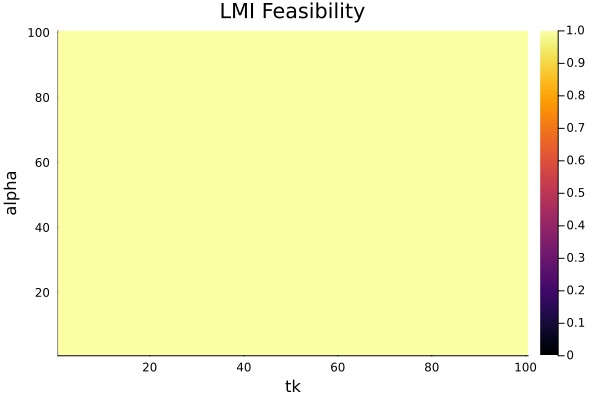

: 

In [ ]:
Plots.heatmap(Float64.(results), x=tk_vec, y=alpha_vec, xlabel="tk", ylabel="alpha", title="LMI Feasibility")

In [ ]:
sol = DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

In [ ]:
Plots.plot(sol, idxs=1, xlim=(0, 100))

# IF integrator

In [ ]:
u = [0.0, 0.0, 0.0, 0.0, 0.0];
input(t) = 2*(t<1);
p = [input, 1, 1, 0.8, 0.1, [], [], [], []];
    
cb1 = DE.ContinuousCallback(if_integrator_condition_1, if_integrator_up_affect_1!, nothing, save_positions=(true, true))
cb2 = DE.ContinuousCallback(if_integrator_condition_2, if_integrator_up_affect_2!, nothing, save_positions=(true, true))
cb3 = DE.ContinuousCallback(if_integrator_condition_3, if_integrator_up_affect_3!, nothing, save_positions=(true, true))
cb4 = DE.ContinuousCallback(if_integrator_condition_4, if_integrator_up_affect_4!, nothing, save_positions=(true, true))
cb = DE.CallbackSet(cb1, cb2, cb3, cb4)
prob = DE.ODEProblem(if_integrator!, u, (0.0, 4.0), p, callback=cb)

In [ ]:
sol = DE.solve(prob, DE.Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9, progress=true);

In [ ]:
spike_avg(t) = (sum([p[6]; t + 1] .< t) - sum([p[7]; t + 1] .< t)) / t

spike_int = spike_avg.(sol.t)

Plots.plot(sol, idxs=3, xlim=(0, 4))
Plots.plot!(sol.t, 2*spike_int, xlim=(0, 4))

In [ ]:

spike_avg(t) = (sum([p[6]; t + 1] .< t) - sum([p[7]; t + 1] .< t)) / t

spike_int = spike_avg.(sol.t)

In [ ]:
[p[6]; [5 + 1]]